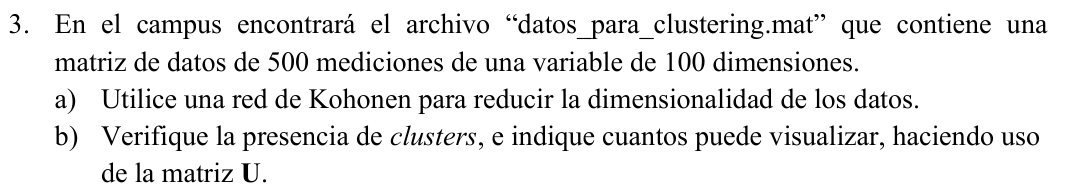

In [ ]:
import numpy as np

class KohonenSOM:
    def __init__(self, grid_rows, grid_cols, input_dim=2,
                 lr=0.1,
                 sigma_initial=None, sigma_final=0.5):

        self.snapshots = []
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.input_dim = input_dim
        self.lr = lr
        self.sigma_initial = sigma_initial if sigma_initial is not None else max(grid_rows, grid_cols) / 2
        self.sigma_final = sigma_final

        self.weights = np.random.uniform(-1, 1, (grid_rows, grid_cols, input_dim))

        rows_idx, cols_idx = np.meshgrid(np.arange(grid_rows), np.arange(grid_cols), indexing='ij')
        self.grid_positions = np.stack([rows_idx, cols_idx], axis=-1).astype(float)
        self.samples = []

    def _decay_sigma(self, t, t_max):
        ratio = self.sigma_final / self.sigma_initial
        return self.sigma_initial * (ratio ** (t / t_max))

    def _get_bmu(self, x):
        diff = self.weights - x
        dist = np.linalg.norm(diff, axis=-1)
        bmu_flat = np.argmin(dist)
        bmu_idx = np.unravel_index(bmu_flat, (self.grid_rows, self.grid_cols))
        return bmu_idx

    def _neighborhood(self, bmu_idx, sigma):
        bmu_pos = self.grid_positions[bmu_idx[0], bmu_idx[1]]
        diff = self.grid_positions - bmu_pos
        dist_sq = np.sum(diff ** 2, axis=-1)
        h = np.exp(-dist_sq / (sigma ** 2))
        return h

    def train(self, n_iterations, sample_fn, snapshot_every=None):
        for t in range(n_iterations):
          sigma = self._decay_sigma(t, n_iterations)
          x = sample_fn()
          self.samples.append(x.copy())
          bmu_idx = self._get_bmu(x)
          h = self._neighborhood(bmu_idx, sigma)
          h_expanded = h[:, :, np.newaxis]
          self.weights += self.lr * h_expanded * (x - self.weights)

          if snapshot_every and (t % snapshot_every == 0 or t == n_iterations - 1):
              self.snapshots.append((t, self.weights.copy()))

    def get_weights(self):
        return self.weights

In [ ]:
!git clone https://github.com/ManuelHirsch1/TP3_rrnn.git

import scipy.io
import numpy as np

# Archivo en la ruta principal del repo
ruta_datos = "/content/TP3_rrnn/datos_para_clustering.mat"

# Cargo el .mat
datos = scipy.io.loadmat(ruta_datos)

# Veo qué variables hay adentro
print("Variables en datos_para_clustering.mat:")
print(datos.keys())

Cloning into 'TP3_rrnn'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 37 (delta 1), reused 36 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 10.75 MiB | 56.73 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Variables en datos_para_clustering.mat:
dict_keys(['__header__', '__version__', '__globals__', 'datos'])


In [ ]:
X = datos['datos']
print(X.shape)
print(X.dtype)

(500, 100)
float32


In [ ]:
def make_epoch_sample_fn(X):
    n = X.shape[0]
    order = np.random.permutation(n)
    pos = [0]  # usamos una lista para poder modificarla dentro de la función interna

    def sample_fn():
        if pos[0] >= n:
            order[:] = np.random.permutation(n)  # nueva época: remezclar
            pos[0] = 0
        idx = order[pos[0]]
        pos[0] += 1
        return X[idx]

    return sample_fn

sample_fn = make_epoch_sample_fn(X)

In [ ]:
som = KohonenSOM(grid_rows=50, grid_cols=50, input_dim=100, sigma_final=0.5)
som.train(n_iterations=20000, sample_fn=sample_fn, snapshot_every=4000)

# esto era lo que la consigna quería decir con "reducir dimensionalidad", no habia que poner ninguna figura

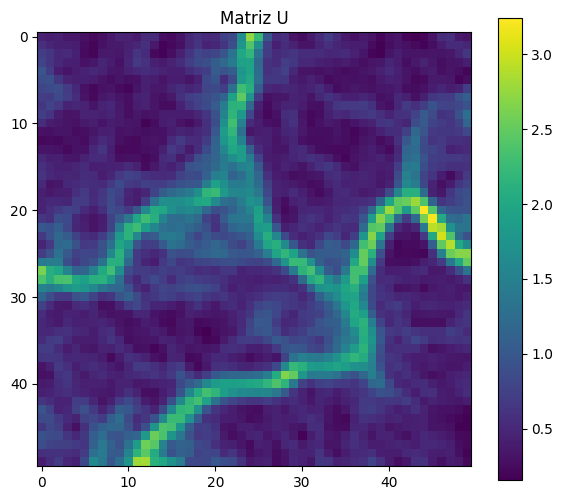

In [ ]:
import matplotlib.pyplot as plt

W = som.get_weights()  # shape (15, 15, 100)

u_matrix = np.zeros((som.grid_rows, som.grid_cols))
for i in range(som.grid_rows):
    for j in range(som.grid_cols):
        vecinos = []
        if i > 0: vecinos.append(W[i-1, j])
        if i < som.grid_rows - 1: vecinos.append(W[i+1, j])
        if j > 0: vecinos.append(W[i, j-1])
        if j < som.grid_cols - 1: vecinos.append(W[i, j+1])
        dists = [np.linalg.norm(W[i, j] - v) for v in vecinos]
        u_matrix[i, j] = np.mean(dists)

plt.figure(figsize=(7, 6))
im = plt.imshow(u_matrix, cmap='viridis')
plt.title("Matriz U")
plt.colorbar(im)
plt.show()